Schema:
Phase 0: Import and reading data 
Phase 1: Data Understanding
Phase 2: Data Cleaning and Validation
Phase 3: Revenue and order trends


Phase 0: Import and reading data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Setting display options to 200 columns for better readability

pd.set_option('display.max_columns', 200)

# Reading a CSV file into a DataFrame
# Note. Ensure the CSV file "Sales Transaction v.4a.csv" is in the same directory as this script or provide the full path to the file.

df = pd.read_csv("Sales Transaction v.4a.csv")

Phase 1: Data Understanding
- Dataframe shape
- head and tail
- dtypes
- describe
- find how many unique customers and products are present
- correct data where necessary

In [ ]:
# Checking how many rows and columns are in the dataset

df.shape

(536350, 8)

In [ ]:
# Checking top 5 rows of the dataset

df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [ ]:
# Checking bottom 5 rows of the dataset

df.tail()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany
536349,C536548,12/1/2018,22767,Triple Photo Frame Cornice,20.45,-2,12472.0,Germany


In [ ]:
# Getting a summary about the dataset, specifically column names, dtypes, and non-null-values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  str    
 1   Date           536350 non-null  str    
 2   ProductNo      536350 non-null  str    
 3   ProductName    536350 non-null  str    
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.7 MB


In [ ]:
# Getting additional information about the dataset to understand values range

df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


Phase 1 completed successfully.

Notes: 
1. Transaction number is "str" type, I should look if there is a reason for that. Maybe convert to "int" if it makes sense further
2. Product number is "str" type, I should look if there is a reason for that. Maybe convert to "int" if it makes sense further
3. Date is "str" type, I should convert it to "date" format
4. Quantity can be negative.
5. Customer number starts from 12004 

Phase 2: Data Cleaning and Validation
- Copy the dataset
- Rename Columns
- Search missing values
- Identify duplicated columns
- Clean columns from redundant data
- Fix dtype where needed

In [ ]:
# Creating a copy of the dataset to work on it without affecting the original dataset
# Copying all columns and rows because I am going to analyse full dataset

df = df.copy()

In [ ]:
# In Step 1, I that noticed 'Date' column has incorrect dtype
# I'm changing dtype formatting by converting the 'Date' column to datetime format

df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Checking the "Date" column's dtype

df.dtypes

TransactionNo               str
Date             datetime64[us]
ProductNo                   str
ProductName                 str
Price                   float64
Quantity                  int64
CustomerNo              float64
Country                     str
dtype: object

In [ ]:
# I decided to rename columns for better representation and readability

df = df.rename(columns={'TransactionNo': 'Order_id',
                    'ProductNo': 'Product_id',
                    'ProductName': 'Product_name',
                    'Price': 'Price_UKpounds',
                    'CustomerNo': 'Customer_id'})

In [ ]:
# Checking the renaming result

df.head()

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [ ]:
# Counting total unique products

df['Product_id'].nunique()

# Result: 3768 unique product numbers, but it will be reviewed further in the analysis of product names

3768

In [ ]:
# Counting total unique customers

df['Customer_id'].nunique()

# Result: 4738 unique customer ids, but it will be checked later in analysis of cutomer ids.

4738

In [ ]:
# Checking for missing data

df.isnull().sum()

Order_id           0
Date               0
Product_id         0
Product_name       0
Price_UKpounds     0
Quantity           0
Customer_id       55
Country            0
dtype: int64

Note.  Customer_id contains 55 NULL entries.

In [ ]:
# Previous operation revealed 55 Customer_id values are missing and probably relate to unidentified users.
# Checking rows with missing Customer_id values.

df.loc[df['Customer_id'].isnull()]

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,NaN,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,NaN,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,NaN,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,NaN,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,NaN,United Kingdom
163160,C569495,2019-10-04,21843,Red Retrospot Cake Stand,21.47,-1,NaN,United Kingdom
190598,C567518,2019-09-20,22846,Bread Bin Diner Style Red,27.62,-1,NaN,United Kingdom
192284,C567518,2019-09-20,21871,Save The Planet Mug,11.94,-12,NaN,United Kingdom
242406,C563015,2019-08-11,46000M,Polyester Filler Pad 45x45cm,10.25,-160,NaN,United Kingdom
242407,C563015,2019-08-11,46000S,Polyester Filler Pad 40x40cm,10.25,-220,NaN,United Kingdom


In [ ]:
# To handle missing values I decided filling NA Customer_id with 0 to keep these rows for investigation purposes.
# The reason is that for some analysis they can be useful, for example for refund analysis. Otherwise, they can be easily filtered out.
# Using "0" is OK because min Customer_id starts with 12004 and so filling NA with "0" will not affect the analysis.

df['Customer_id'] = df['Customer_id'].fillna(0).astype(int) 

In [ ]:
# Checking the updated datset for missing values

df.isna().sum()

# Result: 0

Order_id          0
Date              0
Product_id        0
Product_name      0
Price_UKpounds    0
Quantity          0
Customer_id       0
Country           0
dtype: int64

In [ ]:
# Checking for duplicates

exact_duplicates = df.loc[df.duplicated()]
exact_duplicates

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
985,581497,2019-12-09,21481,Fawn Blue Hot Water Bottle,7.24,1,17497,United Kingdom
1365,581538,2019-12-09,23275,Set Of 3 Hanging Owls Ollie Beak,6.19,1,14446,United Kingdom
1401,581538,2019-12-09,22992,Revolver Wooden Ruler,6.19,1,14446,United Kingdom
1406,581538,2019-12-09,22694,Wicker Star,6.19,1,14446,United Kingdom
1409,581538,2019-12-09,23343,Jumbo Bag Vintage Christmas,6.19,1,14446,United Kingdom
...,...,...,...,...,...,...,...,...
535227,536559,2018-12-01,51014L,Feather Pen Light Pink,11.12,12,17873,United Kingdom
535310,536569,2018-12-01,22111,Scottie Dog Hot Water Bottle,15.32,1,16274,United Kingdom
535327,536569,2018-12-01,21809,Christmas Hanging Tree With Bell,11.53,1,16274,United Kingdom
535960,536592,2018-12-01,82613A,Metal Sign Cupcake Single Hook,12.82,1,16592,United Kingdom


Note. 5200 duplicates found. However, there can be typos in "Product_name". Additionally, "Country" and "Price" should be the same for the same "Order_id".
Therefore, I recheck duplicates ignoring the three columns - "Product_name", "Country", and "Price".

In [ ]:
# Checking the duplicates with the same transaction_id, date, product_id, and customer_id because one transaction may contain multiple products

df.loc[df.duplicated(subset=['Order_id', 'Date', 'Product_id','Quantity', 'Customer_id'])]

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
985,581497,2019-12-09,21481,Fawn Blue Hot Water Bottle,7.24,1,17497,United Kingdom
1321,581514,2019-12-09,22075,6 Ribbons Elegant Christmas,6.19,24,17754,United Kingdom
1365,581538,2019-12-09,23275,Set Of 3 Hanging Owls Ollie Beak,6.19,1,14446,United Kingdom
1384,581538,2019-12-09,22068,Black Pirate Treasure Chest,7.24,1,14446,United Kingdom
1398,581538,2019-12-09,23318,Box Of 6 Mini Vintage Crackers,6.02,1,14446,United Kingdom
...,...,...,...,...,...,...,...,...
535227,536559,2018-12-01,51014L,Feather Pen Light Pink,11.12,12,17873,United Kingdom
535310,536569,2018-12-01,22111,Scottie Dog Hot Water Bottle,15.32,1,16274,United Kingdom
535327,536569,2018-12-01,21809,Christmas Hanging Tree With Bell,11.53,1,16274,United Kingdom
535960,536592,2018-12-01,82613A,Metal Sign Cupcake Single Hook,12.82,1,16592,United Kingdom


Note. Duplicate rows number increased to 5587. I will look into difference between previous 5200 and 5587 rows.

In [ ]:
# Selecting and checking one line that is not completely duplicated (not in list of fully duplicated 5200 rows), but present in newer 5587 duplicated rows list.

df.query('Customer_id == 17754.0 and Product_id == "22075"')

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
1316,581514,2019-12-09,22075,6 Ribbons Elegant Christmas,6.04,24,17754,United Kingdom
1321,581514,2019-12-09,22075,6 Ribbons Elegant Christmas,6.19,24,17754,United Kingdom


In [ ]:
# Selecting and checking another line that is not completely duplicated (not in list of fully duplicated 5200 rows), but present in newer 5587 duplicated rows list.

df.query('Customer_id == 12876.0 and Product_id == "84879"')

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
529759,536876,2018-12-03,84879,Assorted Colour Bird Ornament,13.52,8,12876,Belgium
529848,536876,2018-12-03,84879,Assorted Colour Bird Ornament,11.98,8,12876,Belgium


Note. The results above show that there are two lines with the same information, except "Price". 

In [ ]:
# Logically, I assume that full duplicates are an error and should be removed.
# However, the changes in "Price" should be investigated and validated. Therefore I create a separate dataframe with 
# with entries listing changed Prices creating a cleaning policy. 

# Summarizing the financial results under a cleaning policy.

def summarize_policy(data, policy):
    values = data["Price_UKpounds"] * data["Quantity"]

    return {
        "Policy": policy,
        "Rows": len(data),
        "Gross_sales": values.loc[data["Quantity"] >= 0].sum(),
        "Refunds": -values.loc[data["Quantity"] < 0].sum(),
        "Net_revenue": values.sum()
    }

sensitivity_rows = []

duplicate_key = [
    "Order_id", "Date", "Product_id", "Quantity", "Customer_id"
]

sensitivity_rows.append(                            # adding original dataset
    summarize_policy(df, "Original dataset")
)


In [ ]:
# Policy 1:  identical rows are treated as duplicates.

df = df.drop_duplicates().copy()    # removing duplicates

sensitivity_rows.append(
    summarize_policy(df, "Exact duplicates removed")
)

# Retain every member of each conflicting group for investigation.

price_changed = df.loc[
    df.duplicated(subset=duplicate_key, keep=False) # includes both the retained and discarded candidates in the table
].copy()

price_changed

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
1316,581514,2019-12-09,22075,6 Ribbons Elegant Christmas,6.04,24,17754,United Kingdom
1321,581514,2019-12-09,22075,6 Ribbons Elegant Christmas,6.19,24,17754,United Kingdom
1341,581538,2019-12-09,22068,Black Pirate Treasure Chest,6.19,1,14446,United Kingdom
1366,581538,2019-12-09,23318,Box Of 6 Mini Vintage Crackers,6.19,1,14446,United Kingdom
1384,581538,2019-12-09,22068,Black Pirate Treasure Chest,7.24,1,14446,United Kingdom
...,...,...,...,...,...,...,...,...
529834,536876,2018-12-03,10133,Colouring Pencils Brown Tube,12.82,1,12876,Belgium
529848,536876,2018-12-03,84879,Assorted Colour Bird Ornament,11.98,8,12876,Belgium
530666,536987,2018-12-03,72127,Columbian Candle Round,10.92,1,17198,United Kingdom
530667,536987,2018-12-03,72127,Columbian Candle Round,11.12,1,17198,United Kingdom


In [ ]:
# Policy 2: retain the first source row for each selected key, here - "Price" is the focus

# This is an analytical assumption: the available fields do not
# establish which different-price records represent duplicate entries.

df = df.drop_duplicates(
    subset=duplicate_key,       # this subset excludes "Price" column
    keep="first"                # keeping only first price 
).copy()

sensitivity_rows.append(
    summarize_policy(df, "Also collapse price conflicts")
)

df.info()

<class 'pandas.DataFrame'>
Index: 530763 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Order_id        530763 non-null  str           
 1   Date            530763 non-null  datetime64[us]
 2   Product_id      530763 non-null  str           
 3   Product_name    530763 non-null  str           
 4   Price_UKpounds  530763 non-null  float64       
 5   Quantity        530763 non-null  int64         
 6   Customer_id     530763 non-null  int64         
 7   Country         530763 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 36.4 MB


Note. Duplicates removed. 
Additionally, following an asumption above, difference in "Price" for same "Products" but different "Orders" are treated as duplicate rows.

Note. Next, I am checking why "Product_id" is "str" dtype

In [ ]:
# Checking if there are any products with the same "Product_id" but different "Product_name", which may indicate a data entry error

unique_products = (
    df[['Product_id', 'Product_name']]
    .drop_duplicates()
    .sort_values(['Product_id'])
)

print(unique_products.duplicated().sum())
print(unique_products)

0
       Product_id                 Product_name
375995      10002   Inflatable Political Globe
55466       10080     Groovy Cactus Inflatable
18585       10120                 Doggy Rubber
396291     10123C         Hearts Wrapping Tape
97772      10124A  Spots On Red Bookcover Tape
...           ...                          ...
15152      90214U    Letter "U" Bling Key Ring
15153      90214V    Letter "V" Bling Key Ring
15154      90214W    Letter "W" Bling Key Ring
12042      90214Y    Letter "Y" Bling Key Ring
15156      90214Z    Letter "Z" Bling Key Ring

[3768 rows x 2 columns]


Note. "Product_id" is a combination of number and a letter. Letter has a meaning with regard to a "Product_name". 
However, the product type is the same. It is better to keep unique "Product_id" for each product so I will keep it unchanged for now.

Note. I noticed symbols are used in "Product_name". I would investigate further.

In [ ]:
# Checking "Product_name" column for names with "&" symbol

df.loc[
    df['Product_name'].str.contains('&', regex=False, na=False),
    'Product_name'
].unique()

<StringArray>
[ 'Playing Cards Keep Calm & Carry On',       'Traditional Naughts & Crosses',
       'Pink Rosebud & Pearl Necklace',       'Drop Earrings W Flower & Leaf',
            'Vintage Snakes & Ladders',       'Ladies & Gentlemen Metal Sign',
      'Pig Keyring With Light & Sound',               'Wall Art Horse & Pony',
            'Cinammon & Orange Wreath',      'Gin & Tonic Diet Greeting Card',
           'Pink & White Rosebud Ring', 'Large Hanging Ivory & Red Wood Bird',
   'Vintage Enamel & Crystal Earrings',  'Charlie & Lola Wastepaper Bin Blue',
      'White Rosebud & Pearl Necklace',         'Booze & Women Greeting Card',
 'Charlie & Lola Wastepaper Bin Flora',             'Teatime Pen Case & Pens',
    'Set 10 Xmas Cards & Badges 17070', 'Set 10 Cards Hats & Stockings 17081',
        'Eucalyptus & Pinecone Wreath',   'Set 10 Mini Santa & Snowman 17087',
   'Vintage Enamel & Crystal Necklace',   'Polkadot Coffee Cup & Saucer Pink',
         'Blue & White Breakfast Tray'

In [ ]:
# Checking "Product_name" column for names with "and" conjunction

df.loc[
    df['Product_name'].str.contains(' and ', regex=False, na=False),
    'Product_name'
].unique()

<StringArray>
[]
Length: 0, dtype: str

In [ ]:
# Checking "Product_name" column for names with "+" symbol

df.loc[
    df['Product_name'].str.contains('+', regex=False, na=False),
    'Product_name'
].unique()

<StringArray>
[        'Door Hanger Mum + Dads Room',   'Charlie+Lola Red Hot Water Bottle',
     'Carrot Charlie+Lola Coaster Set',        'Coffee Mug Dog + Ball Design',
        'Coffee Mug Cat + Bird Design',         'Office Mug Warmer Choc+Blue',
  'Charlie+Lola Pink Hot Water Bottle', 'Charlie + Lola Red Hot Water Bottle',
   'Charlie+Lola"Extremely Busy" Sign',     'Tomato Charlie+Lola Coaster Set',
    'Woodland Party Bag + Sticker Set',           'Ribbon Reel Flora + Fauna',
        '200 Red + White Bendy Straws',        'Painted Lightbulb Star+ Moon',
   'Ceramic Cake Bowl + Hanging Cakes',    'Turq+Red Boudicca Large Bracelet',
  'Red Charlie+Lola Personal Doorsign',        'Rex Cash+Carry Jumbo Shopper',
   'Retrospot Party Bag + Sticker Set',    'Dinosaur Party Bag + Sticker Set',
  'Ceramic Cake Stand + Hanging Cakes', 'Necklace+Bracelet Set Blue Hibiscus',
      'Charlie+Lola My Room Door Sign', 'Blue Charlie+Lola Personal Doorsign',
      'Office Mug Warmer Black+Silver'

Note. I checked "Product_name" column for names containing "+", "&" symbols which have the same meaning as "and" conjunction. There are 32 former and 52 latter.
I should unify "Product_name" names. I decided to substitute "+" with "&" for better readability and name unification. 

In [ ]:
# Substitute "+" symbol from the Product_name column to "&" to make it more readable and easier to work with

df['Product_name'] = df['Product_name'].str.replace('+', ' & ')

In [ ]:
# Checking the updated dataset for "+" symbol

df.loc[
    df['Product_name'].str.contains('+', regex=False, na=False),
    'Product_name'
].unique()

<StringArray>
[]
Length: 0, dtype: str

In [ ]:
# Approach above introduced extra spaces in the Product_name column, 
# so I am removing extra spaces by substituting multiple spaces with a single space

df['Product_name'] = df['Product_name'].str.replace(r'\s+', ' ', regex=True)

# Checking the updated dataset for a double space "  " symbol
df.loc[
    df['Product_name'].str.contains(' and ', regex=False, na=False),
    'Product_name'
].unique()

# Result: 0

<StringArray>
[]
Length: 0, dtype: str

In [ ]:
# Checking the updated dataset for a double space "_" symbol
df.loc[
    df['Product_name'].str.contains('_', regex=False, na=False),
    'Product_name'
].unique()

# Result: 0

<StringArray>
[]
Length: 0, dtype: str

In [ ]:
# Checking if there are any products with the same product_id but different product_name

unique_products = (
    df[['Product_id', 'Product_name']]
    .drop_duplicates()
    .sort_values(['Product_id'])
)

print(unique_products.duplicated().sum())

# Result: 0.
# 'Product_name' is updated for clarity with symbols removed.

0


Note. 
I noticed that letter "C" in "Order_id" column stands for refunds
I should check if "Order_id" numbers with "C" are unique and that there are no positive values in "Quantity" column associated with "Order_id" starting with "C" letter

In [ ]:
# I am checking that numbers of "Order_id" without "C" do not match with ids that were originally without "C" 

# Step 1. Creating a list of "Order_ids" without duplicates

original_c = df['Order_id'].drop_duplicates() # list of all "Order_ids" with and without "C" without duplicates


# Step 2. Creating and filling two lists, one for ids without "C" and one for ids which had "C" but I removed it

no_c = [] # list of numbers that didn't start with "C" 
deleted_c = [] # list of numbers that started with "C" but we removed the "C" letter

for i in original_c:
    if i.startswith('C'):
        i = i.replace('C','')
        deleted_c.append(i)
    else:
        no_c.append(i)
#print(deleted_c)
#print(no_c)


# Step 3. Checking that there are no matches between lists

h = 0
for n in deleted_c:
    if n in no_c:
        print(f'Match found:',n)
    else:
        h += 1
        continue

if h == len(deleted_c):
    print('No matches found. All IDs are unique.')
    
# Result: 
# No matches found, meaning that "C" letters can be safely removed. All ids are unique.

No matches found. All IDs are unique.


In [ ]:
# Additionally, I am checking that there are no positive "Quantity" values associated with "Order_id" starting with "C" 

check_c = df.loc[
    df['Order_id'].str.startswith('C', na=False),
    ['Order_id', 'Quantity']
]

result_c = check_c.loc[check_c['Quantity'] >= 0].sum()
print(result_c)

# Result is 0. No positive values were found and thus all negative quantitiy values directly indicate refunds.


Order_id    0.0
Quantity    0.0
dtype: float64


Note. Cancellations are straightforwardly identified both, by letter "C" in "Order_id" and by "Quantity" negative values. Additionally, the cancalled numbers of "Order_id" numbers don't match with normal transactions "Order_id"s. I decided to keep it and thus the 'Order_id' remains in 'str' dtype.

Optional Step: "C" letter in "Order_id" can be deleted and then "Order_id" column can be converted to "int" format, see below. 

Optional Step:

In [ ]:
# Removing "C" letter from the "Order_id"s and updating the respective column

# df['Order_id']= df['Order_id'].str.replace('C', '')

# Now, all 'Order_id' are numbers but their dtypes is 'str'.
# So I'm changing dtype format of the 'Order_id' column to numeric format

# df['Order_id'] = pd.to_numeric(df['Order_id'])

# Checking dtypes format

# df.dtypes

# Rechecking for duplicates after cleaning the Product_name column

# df.loc[df.duplicated()]

Note: I noticed that not everyone are aware that Ireland is called 'Eire' so I want to clarify it in the Country name in the dataset.

In [ ]:
# Changing the "Country" name "EIRE" to "Ireland(EIRE)" to make it more clear

df['Country'] = df['Country'].replace('EIRE', 'Ireland(EIRE)')

df['Country'].unique() # checking country names after the change

<StringArray>
[      'United Kingdom',               'Norway',              'Belgium',
              'Germany',               'France',              'Austria',
          'Netherlands',        'Ireland(EIRE)',                  'USA',
      'Channel Islands',              'Iceland',             'Portugal',
                'Spain',              'Finland',                'Italy',
               'Greece',                'Japan',               'Sweden',
              'Denmark',               'Cyprus',                'Malta',
          'Switzerland',            'Australia',       'Czech Republic',
               'Poland',            'Hong Kong',            'Singapore',
                  'RSA',               'Israel',          'Unspecified',
 'United Arab Emirates',               'Canada',   'European Community',
              'Bahrain',               'Brazil',         'Saudi Arabia',
              'Lebanon',            'Lithuania']
Length: 38, dtype: str

I will look into 'Quantity' column checking that there are no negative values

In [ ]:
# Checking for negative "Quantity" for products sold

check_quantity = df.copy() 

check_quantity['total_sold'] = check_quantity.query('Quantity >= 0')['Quantity']
check_quantity['total_cancelled'] = check_quantity.query('Quantity < 0')['Quantity'].abs()

check_quantity = check_quantity.groupby('Product_name').agg(
    total = ('Quantity', 'sum'),
    total_sold = ('total_sold', 'sum'),
    total_cancelled = ('total_cancelled', 'sum'))

negative_returns = check_quantity.query('total_sold < total_cancelled')
print(f'Total items: {check_quantity['total'].count()}, Negative returns: {negative_returns['total'].count()}') 

# These products have more credited units than sold units within the observation window.
# Their original purchases may fall before that window. Therfore, I exclude these products under the chosen analysis policy 
# and measure the effect in the sensitivity table.

negative_returns.sort_values('total_cancelled', ascending=False)

Total items: 3767, Negative returns: 22


,total,total_sold,total_cancelled
Product_name,,,
Travel Card Wallet Dotcomgiftshop,-200,0.0,200.0
Pink Small Glass Cake Stand,-3,24.0,27.0
Assorted Tutti Frutti Round Box,-24,0.0,24.0
Wooden Box Advent Calendar,-6,10.0,16.0
Pink Poodle Hanging Decoration,-7,5.0,12.0
Robin Christmas Card,-2,10.0,12.0
Pink Cherry Lights,-4,4.0,8.0
White Cherry Lights,-8,0.0,8.0
Blue Padded Soft Mobile,-6,1.0,7.0


Note. As a result of finding negative "Quantities" of sold Products, which may be connected to a limited purchase history,
I decided to update duplicates removal policy by including the found Products with negative sales values. 
It will impact following calculations and analysis, but this decision aims at getting cleaner and meaningful data.

In [ ]:
# Duplicates Policy update
# Policy 3: exclude lines belonging to the flagged products.

removed_products = negative_returns.index.tolist()         # converting the products found above (negative sales) to list of Product names

exclude_mask = df["Product_name"].isin(removed_products)   # finding rows related tot he products in the dataset

# Preserve excluded records for investigation.

excluded_product_rows = df.loc[exclude_mask].copy()         # keeping the rows that will be deleted as a separate table

# Apply the selected policy.

df = df.loc[~exclude_mask].copy()                           # removing the rows associated with the flagged products

sensitivity_rows.append(
    summarize_policy(df, "Also exclude flagged products")
)

print(f"Excluded products: {len(removed_products):,}")
print(f"Excluded transaction lines: {len(excluded_product_rows):,}")

df.info()

Excluded products: 22
Excluded transaction lines: 51
<class 'pandas.DataFrame'>
Index: 530712 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Order_id        530712 non-null  str           
 1   Date            530712 non-null  datetime64[us]
 2   Product_id      530712 non-null  str           
 3   Product_name    530712 non-null  str           
 4   Price_UKpounds  530712 non-null  float64       
 5   Quantity        530712 non-null  int64         
 6   Customer_id     530712 non-null  int64         
 7   Country         530712 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 36.4 MB


In [ ]:
# Summary of cleaning Policy impact on the dataset

cleaning_sensitivity = pd.DataFrame(sensitivity_rows)

cleaning_sensitivity["Net_change_from_previous"] = (
    cleaning_sensitivity["Net_revenue"].diff()
)

display(cleaning_sensitivity.round(2))

,Policy,Rows,Gross_sales,Refunds,Net_revenue,Net_change_from_previous
0,Original dataset,536350,62965974.34,2685950.08,60280024.26,NaN
1,Exact duplicates removed,531150,62781386.54,2664628.15,60116758.39,-163265.87
2,Also collapse price conflicts,530763,62770010.56,2655353.63,60114656.93,-2101.46
3,Also exclude flagged products,530712,62769232.32,2651359.56,60117872.76,3215.83


Phase 2 were completed successfully.

Notes: The data was cleaned from erratic or redundant data, ambigous data was clarified. Altogether the dataset was validated and prepared for further data analysis.


Phase 3: Revenue and order trends

- Total gross revenue, net revenue and total refunds
- Time range of the dataset
- Monthly net and gross revenue and refunds trends
- Monthly revenue pattern within the observed year
- 3-Month net and gross revenue and refunds trend 
- Transaction Volume vs Revenue and Transaction Volume vs Quantity of ordered items
- Variation of monthly revenue (volatility) within 12 Months
- Recency, Frequency, Monetary (RFM) analysis for Revenue
- Cohort and retention analysis of customers
- Countries performance analysis
- Products cancellation analysis

Gross revenue, net revenue and total refunds in the cleaned and validated dataset

In [ ]:
# Calculating net revenue per transaction

net_revenue = df['Price_UKpounds'] * df['Quantity']
print((net_revenue).sum())


# Calculating total gross revenue

gross_revenue = df['Price_UKpounds'] * df.query('Quantity >= 0')['Quantity']
print((gross_revenue).sum())

# Calculating total refunds

refunds = -1 * (df['Price_UKpounds'] * df.query('Quantity < 0')['Quantity'])
print(refunds.sum())

# Checking if the sum of gross revenue and refunds equals net revenue

print((gross_revenue.sum() - refunds.sum()) == net_revenue.sum())

60117872.760000005
62769232.32
2651359.56
False


Result:
Gross revenue: 62769232.32
Net revenue:   60117872.76
Refunds:       2651359.56


Time range of the dataset

In [ ]:
# Finding the date range of the dataset

print(df['Date'].agg(['min', 'max']))


# Calculating total number of days in the datset

datediff = df['Date'].max() - df['Date'].min()
print(datediff)

min   2018-12-01
max   2019-12-09
Name: Date, dtype: datetime64[us]
373 days 00:00:00


Result: 
The full dataset is 1 year and 8 days (373 days). 

In [ ]:
# Additional step:

# For correct monthly analysis, I should ignore extra days in December 2019.
# Therefore, creating a copy of dataset which excludes data related to 2019-12-01 - 2019-12-09 period

one_year_df = df.copy()
one_year_df = one_year_df.loc[~df['Date'].between('2019-12-1', '2019-12-09')]
one_year_df.sort_values('Date').tail()

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
27635,579777,2019-11-30,90197B,Black Glass Bracelet W Heart Charms,7.24,1,13777,United Kingdom
27634,579777,2019-11-30,90181A,Amber Glass/Shell/Pearl Necklace,7.24,1,13777,United Kingdom
27633,579777,2019-11-30,90180B,Purple Amethyst Necklace W Tassel,7.24,1,13777,United Kingdom
27631,579777,2019-11-30,90170,Daisy Hair Band,7.24,2,13777,United Kingdom
25361,579522,2019-11-30,84879,Assorted Colour Bird Ornament,6.04,8,14432,United Kingdom


Monthly net and gross revenue and refunds trends

Note. Data related to December 2019 is ignored in the following analysis due to being incomplete and therefore not useful.

In [ ]:
# Monthly net revenue trend

one_year_df['Month'] = one_year_df['Date'].dt.to_period('M') # converting date to monthly period, i.e. removing day and time
print(f"From this step, period-based data investigation covers {len(one_year_df['Month'].unique())} months from {one_year_df['Month'].min()} till {one_year_df['Month'].max()}")
print("\t")

monthly_net_revenue = one_year_df.groupby('Month').apply(lambda x: (x['Price_UKpounds'] * x['Quantity']).sum())
print(monthly_net_revenue)

From this step, period-based data investigation covers 12 months from 2018-12 till 2019-11
	
Month
2018-12    4214411.99
2019-01    3638782.43
2019-02    3291883.57
2019-03    4339213.81
2019-04    3405602.98
2019-05    4521138.99
2019-06    4401159.02
2019-07    4497599.03
2019-08    4604907.07
2019-09    6528816.05
2019-10    6974087.55
2019-11    7710150.20
Freq: M, dtype: float64


In [ ]:
# Monthly gross revenue trend

one_year_df['Month'] = one_year_df['Date'].dt.to_period('M')

# First, our table should be filtered to remove refunds

monthly_gross_revenue = (
    one_year_df[one_year_df['Quantity'] >= 0]                               # filtering rows with positive 'Quantity' column values
    .assign(gross_revenue=lambda x: x['Price_UKpounds'] * x['Quantity'])    # creating a temporary column 'gross_revenue' filling it with values set by lambda function
    .groupby('Month')['gross_revenue']                                      # grouping our newly created 'gross_revenue' column by 'Month'
    .sum()
)

print(monthly_gross_revenue)

Month
2018-12    4394623.02
2019-01    4548026.55
2019-02    3327112.13
2019-03    4383906.76
2019-04    3578829.22
2019-05    4569225.53
2019-06    4485385.79
2019-07    4571055.92
2019-08    4749006.27
2019-09    6613332.39
2019-10    7212108.87
2019-11    7825803.42
Freq: M, Name: gross_revenue, dtype: float64


In [ ]:
# Monthly refunds revenue trend

one_year_df['Month'] = one_year_df['Date'].dt.to_period('M')

monthly_refunds = (
    one_year_df[one_year_df['Quantity'] < 0]                                    # filtering out rows with positive 'Quantity' column values
    .assign(refund_value=lambda x: x['Price_UKpounds'] * x['Quantity'] * -1)    # creating a temporary column 'refund_value'
    .groupby('Month')['refund_value']                                           # grouping our newly created 'refund_value' column by 'Month'
    .sum()
)

print(monthly_refunds)

Month
2018-12    180211.03
2019-01    909244.12
2019-02     35228.56
2019-03     44692.95
2019-04    173226.24
2019-05     48086.54
2019-06     84226.77
2019-07     73456.89
2019-08    144099.20
2019-09     84516.34
2019-10    238021.32
2019-11    115653.22
Freq: M, Name: refund_value, dtype: float64


In [ ]:
# Checking if monthly gross revenue with monthly refunds equals monthly net revenue

check = np.isclose(                                             # because of float dtype the exact comparison fails, so I am using np.isclose() to check values
    monthly_gross_revenue.sub(monthly_refunds, fill_value=0),
    monthly_net_revenue
)

print(check.all())          # checking all months at once

True


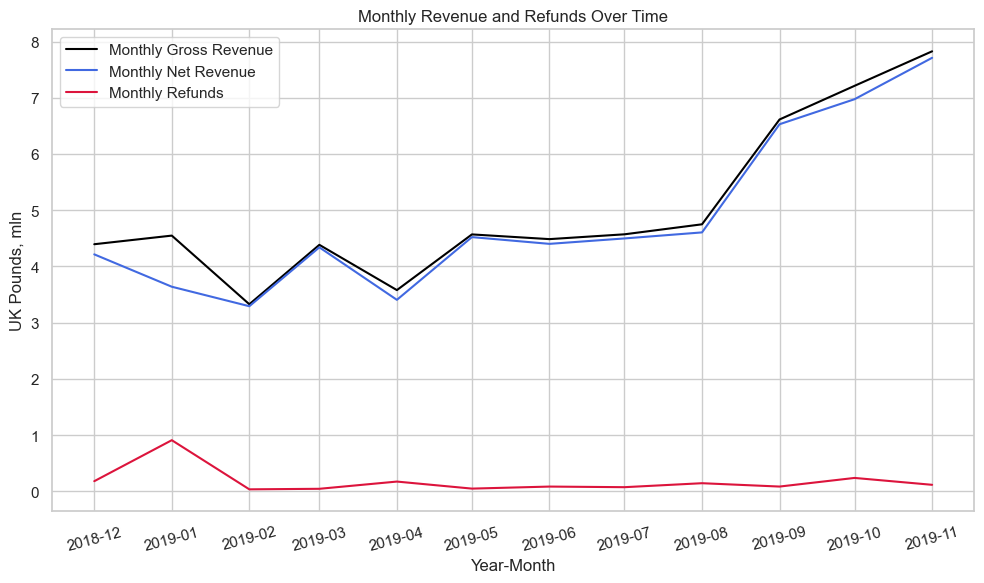

In [ ]:
# Plotting results

# Combining monthly series and convert Period values for plotting

plot_data = pd.concat(
    {
        "Gross_revenue": monthly_gross_revenue/1000000,  # dividing by 1 mln for simplifying plot's Y-label
        "Net_revenue": monthly_net_revenue/1000000,
        "Refunds": monthly_refunds/1000000,
    },
    axis=1
).reset_index()

plot_data["Month"] = plot_data["Month"].dt.to_timestamp()

gross_revenue_plot = plot_data[["Month", "Gross_revenue"]]
net_revenue_plot = plot_data[["Month", "Net_revenue"]]
monthly_refunds_plot = plot_data[["Month", "Refunds"]]

# Creating a plot

import matplotlib.dates as mdates   

sns.set_theme(style="whitegrid")

# Plotting the data

fig, ax = plt.subplots(figsize=(10,6))

# Setting data and axes for line plot for month 

sns.lineplot(
    data=gross_revenue_plot,
    x="Month",
    y="Gross_revenue",
    ax=ax,
    color="black",       
    label="Monthly Gross Revenue",
    
)   

sns.lineplot(
    data=net_revenue_plot,
    x="Month",
    y="Net_revenue",
    ax=ax,
    color="royalblue",
    label="Monthly Net Revenue",
    
) 

sns.lineplot(
    data=monthly_refunds_plot,
    x="Month",
    y="Refunds",
    ax=ax,
    color="crimson",
    label="Monthly Refunds",
    
) 


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.set_title("Monthly Revenue and Refunds Over Time")
ax.set_xlabel("Year-Month")
ax.set_ylabel("UK Pounds, mln")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.show()

Result:
Data indicates a trend of rising revenue with time while refunds remain nearly stable throught the investigated period. 

Monthly revenue pattern within the observed year

Note. Data related to December 2019 is ignored in the following analysis due to being incomplete and therefore not useful.

In [ ]:
# Monthly pattern within the observed year (seasonality is not possible as it requires multiple years)

import calendar  # importing calendar module to get months names 

monthly_seasonality_net_revenue = (                         # calculating average monthly net revenue by grouping 
    monthly_net_revenue                                     # the monthly net revenue by month and calculating the mean for each month
    .groupby(monthly_net_revenue.index.month)
    .mean()
    .rename('average_net_revenue')                          # converting a Series to a DataFrame to create a column with a given name
    .to_frame()
)

monthly_seasonality_net_revenue['rank'] = (                 # ranking the average monthly net revenue in descending order,
    monthly_seasonality_net_revenue['average_net_revenue']  # with the highest average net revenue receiving a rank of 1
    .rank(method='dense', ascending=False)
    .astype(int)
)

monthly_seasonality_net_revenue['month_name'] = (           # mapping the month numbers to their corresponding month names using the calendar module
    monthly_seasonality_net_revenue.index
    .map(lambda month: calendar.month_name[month])
)

monthly_seasonality_net_revenue = (                         # sorting the DataFrame by rank and selecting only the relevant columns for display
    monthly_seasonality_net_revenue
    .sort_values('rank')
    [['month_name', 'average_net_revenue', 'rank']]
)

print(monthly_seasonality_net_revenue)

      month_name  average_net_revenue  rank
Month                                      
11      November           7710150.20     1
10       October           6974087.55     2
9      September           6528816.05     3
8         August           4604907.07     4
5            May           4521138.99     5
7           July           4497599.03     6
6           June           4401159.02     7
3          March           4339213.81     8
12      December           4214411.99     9
1        January           3638782.43    10
4          April           3405602.98    11
2       February           3291883.57    12


Result: 
Months were ranked basing on the average monthly net revenue. November, October, and September were assigned 1,2,3 ranks respectively
having the highest revenue, while January, April, and February were 10,11,12 ranks, respectively. This analysis is usefull to optimize buisness strateagy.

In [ ]:
# Month-over-Month (MoM) Net Revenue Change

mom_net_revenue_change = monthly_net_revenue.pct_change() * 100
print(f"Net revenue - % month over month :{mom_net_revenue_change}")

# Month-over-Month (MoM) Gross Revenue Change

mom_gross_revenue_change = monthly_gross_revenue.pct_change() * 100
print(f"Gross revenue - % month over month :{mom_gross_revenue_change}")

# Month-over-Month (MoM) Refunds Change

mom_refunds_change = monthly_refunds.pct_change() * 100
print(f"Refunds change - % month over month :{mom_refunds_change}")

Net revenue - % month over month :Month
2018-12          NaN
2019-01   -13.658597
2019-02    -9.533377
2019-03    31.815531
2019-04   -21.515668
2019-05    32.755903
2019-06    -2.653755
2019-07     2.191241
2019-08     2.385896
2019-09    41.779540
2019-10     6.820096
2019-11    10.554250
Freq: M, dtype: float64
Gross revenue - % month over month :Month
2018-12          NaN
2019-01     3.490710
2019-02   -26.844927
2019-03    31.763120
2019-04   -18.364386
2019-05    27.673752
2019-06    -1.834879
2019-07     1.909984
2019-08     3.892981
2019-09    39.257184
2019-10     9.054081
2019-11     8.509225
Freq: M, Name: gross_revenue, dtype: float64
Refunds change - % month over month :Month
2018-12           NaN
2019-01    404.544100
2019-02    -96.125511
2019-03     26.865674
2019-04    287.591869
2019-05    -72.240614
2019-06     75.156645
2019-07    -12.786766
2019-08     96.168392
2019-09    -41.348502
2019-10    181.627576
2019-11    -51.410563
Freq: M, Name: refund_value, dtype: fl

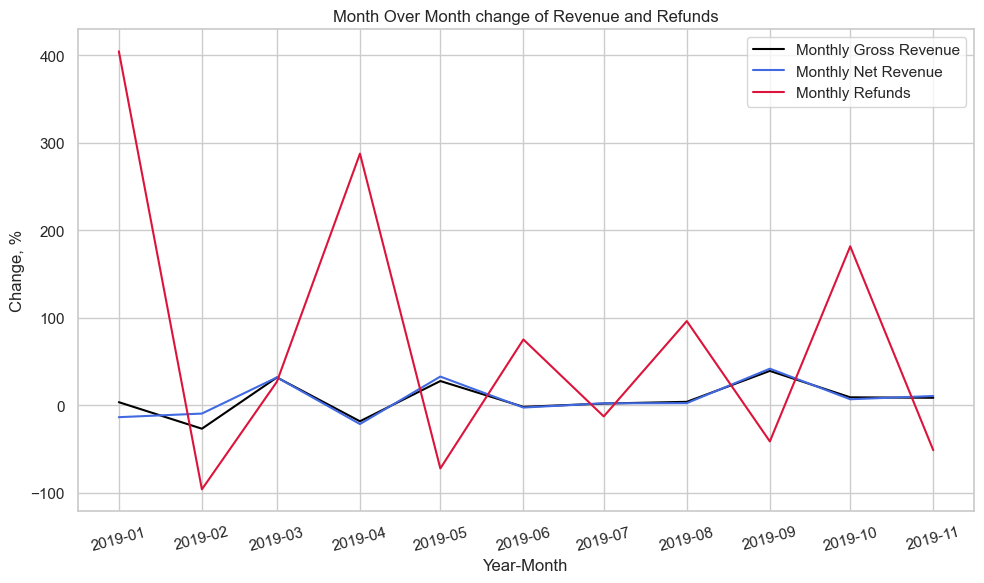

In [ ]:
# Plotting results 

# Combining monthly series and convert Period values for plotting

plot_data = pd.concat(
    {
        "Gross_revenue": mom_gross_revenue_change,  
        "Net_revenue": mom_net_revenue_change,
        "Refunds": mom_refunds_change,
    },
    axis=1
).round(2).reset_index()

plot_data["Month"] = plot_data["Month"].dt.to_timestamp()

gross_revenue_plot = plot_data[["Month", "Gross_revenue"]]
net_revenue_plot = plot_data[["Month", "Net_revenue"]]
monthly_refunds_plot = plot_data[["Month", "Refunds"]]

# Creating a plot 

sns.set_theme(style="whitegrid")

# Plotting the data

fig, ax = plt.subplots(figsize=(10,6))

# Setting data and axes for line plot for month 

sns.lineplot(
    data=gross_revenue_plot,
    x="Month",
    y="Gross_revenue",
    ax=ax,
    color="black",       
    label="Monthly Gross Revenue",
    
)   

sns.lineplot(
    data=net_revenue_plot,
    x="Month",
    y="Net_revenue",
    ax=ax,
    color="royalblue",
    label="Monthly Net Revenue",
    
) 

sns.lineplot(
    data=monthly_refunds_plot,
    x="Month",
    y="Refunds",
    ax=ax,
    color="crimson",
    label="Monthly Refunds",
    
) 


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.set_title("Month Over Month change of Revenue and Refunds")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Change, %")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.show()

Result:
Data indicates that revenue change month over month lies within 50%. Refunds trend has higher changes while their total values are much lower than for revenue.

3-Month net and gross revenue and refunds trends

In [ ]:
# Month-over-3-Month (MoM) Net Revenue Change

mo3m_net_revenue_change = monthly_net_revenue.pct_change(periods=3) * 100
print(f"Net revenue change - % Month over 3-months :{mo3m_net_revenue_change}")

# Month-over-3-Month (MoM) Gross Revenue Change

mo3m_gross_revenue_change = monthly_gross_revenue.pct_change(periods=3) * 100
print(f"Gross revenue change - % Month over 3-months :{mo3m_gross_revenue_change}")

# Month-over-3-Month (MoM) Refund Change

mo3m_refunds_change = monthly_refunds.pct_change(periods=3) * 100
print(f"Refunds change - % Month over 3-months :{mo3m_refunds_change}")

Net revenue change - % Month over 3-months :Month
2018-12          NaN
2019-01          NaN
2019-02          NaN
2019-03     2.961310
2019-04    -6.408172
2019-05    37.342008
2019-06     1.427568
2019-07    32.064690
2019-08     1.852809
2019-09    48.343107
2019-10    55.062457
2019-11    67.433351
Freq: M, dtype: float64
Gross revenue change - % Month over 3-months :Month
2018-12          NaN
2019-01          NaN
2019-02          NaN
2019-03    -0.243849
2019-04   -21.310283
2019-05    37.333079
2019-06     2.314808
2019-07    27.724897
2019-08     3.934600
2019-09    47.441774
2019-10    57.777743
2019-11    64.788231
Freq: M, Name: gross_revenue, dtype: float64
Refunds change - % Month over 3-months :Month
2018-12           NaN
2019-01           NaN
2019-02           NaN
2019-03    -75.199659
2019-04    -80.948324
2019-05     36.498739
2019-06     88.456502
2019-07    -57.594825
2019-08    199.666393
2019-09      0.343798
2019-10    224.028583
2019-11    -19.740554
Freq: M, Name: 

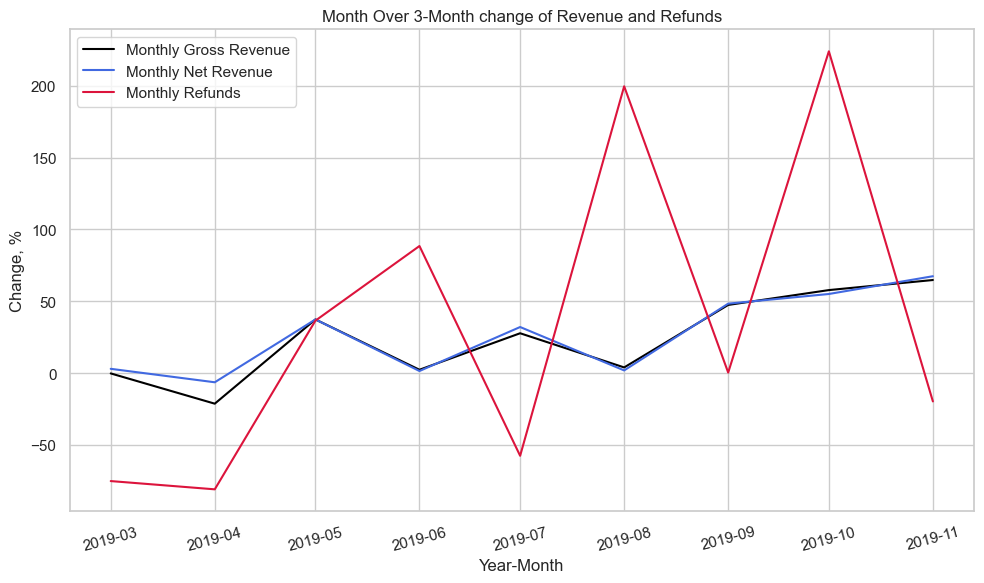

In [ ]:
# Plotting results 

# Combine monthly series and convert Period values for plotting

plot_data = pd.concat(
    {
        "Gross_revenue": mo3m_gross_revenue_change,  
        "Net_revenue": mo3m_net_revenue_change,
        "Refunds": mo3m_refunds_change,
    },
    axis=1
).round(2).reset_index()

plot_data["Month"] = plot_data["Month"].dt.to_timestamp()

gross_revenue_plot = plot_data[["Month", "Gross_revenue"]]
net_revenue_plot = plot_data[["Month", "Net_revenue"]]
monthly_refunds_plot = plot_data[["Month", "Refunds"]]

# Creating a plot 

sns.set_theme(style="whitegrid")

# Plotting the data

fig, ax = plt.subplots(figsize=(10,6))

# Setting data and axes for line plot for month 

sns.lineplot(
    data=gross_revenue_plot,
    x="Month",
    y="Gross_revenue",
    ax=ax,
    color="black",       
    label="Monthly Gross Revenue",
    
)   

sns.lineplot(
    data=net_revenue_plot,
    x="Month",
    y="Net_revenue",
    ax=ax,
    color="royalblue",
    label="Monthly Net Revenue",
    
) 

sns.lineplot(
    data=monthly_refunds_plot,
    x="Month",
    y="Refunds",
    ax=ax,
    color="crimson",
    label="Monthly Refunds",
    
) 


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.set_title("Month Over 3-Month change of Revenue and Refunds")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Change, %")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.show()

Result:
Data trends indicate rise in revenue and refunds with time when compared month over 3 months.

Transaction Volume vs Revenue and Transaction Volume vs Quantity of ordered items

Note. Data related to December 2019 is ignored in the following analysis due to being incomplete and therefore not useful.

In [ ]:
# Transaction Volume vs Revenue
# Note: I will calculate the Revenue per Transaction with refunds excluded, because refunds are not transactions.

# Preparing "Date" and converting it to months

one_year_df['Month'] = one_year_df['Date'].dt.to_period('M')

# Calculating monthly gross revenue 

monthly_gross_revenue = (
    one_year_df[one_year_df['Quantity'] >= 0]                                        
    .assign(Gross_revenue=lambda x: x['Price_UKpounds'] * x['Quantity'])    # create a temporary column 'Gross_revenue'
    .groupby('Month')['Gross_revenue']                                      # group our newly created 'Gross_revenue' column by 'Month'
    .sum()
    .to_frame()
)

# Counting monthly unique transactions

monthly_transactions = (
    one_year_df[one_year_df['Quantity'] >= 0]
    .groupby('Month')['Order_id']
    .nunique()
    .rename('Transactions_count')
    .to_frame()
)

# Combining monthly gross revenue and monthly transactions into a single DataFrame to calculate Gross Revenue per Transaction

Monthly_Volume_vs_Revenue = monthly_transactions.join(monthly_gross_revenue)

# Calculating Volume vs Revenue 

Monthly_Volume_vs_Revenue =  Monthly_Volume_vs_Revenue.assign(Avg_Gross_Revenue_per_Transaction=lambda x: x['Gross_revenue'] / x['Transactions_count']).round(2).sort_values('Month',ascending=True)

# Adding a ranking starting from the lowest Avg_Gross_Revenue_per_Transaction

Monthly_Volume_vs_Revenue = Monthly_Volume_vs_Revenue.assign(RT_Rank=lambda x: x['Avg_Gross_Revenue_per_Transaction'].rank(method='dense', ascending=False).astype(int))

print(Monthly_Volume_vs_Revenue)


         Transactions_count  Gross_revenue  Avg_Gross_Revenue_per_Transaction  \
Month                                                                           
2018-12                1552     4394623.02                            2831.59   
2019-01                1081     4548026.55                            4207.24   
2019-02                1095     3327112.13                            3038.46   
2019-03                1442     4383906.76                            3040.16   
2019-04                1235     3578829.22                            2897.84   
2019-05                1670     4569225.53                            2736.06   
2019-06                1528     4485385.79                            2935.46   
2019-07                1452     4571055.92                            3148.11   
2019-08                1341     4749006.27                            3541.39   
2019-09                1818     6613332.39                            3637.70   
2019-10                2005 

In [ ]:
# Items Volume vs Revenue
# Note: I will calculate the Revenue per Quantity with refunds excluded, because refunds are not transactions.

# Preparing date converting it to months

one_year_df['Month'] = one_year_df['Date'].dt.to_period('M')

# Calculating monthly gross revenue 
monthly_gross_quantity = (
    one_year_df[one_year_df['Quantity'] >= 0]                                        
    .groupby('Month')['Quantity']                            # group our newly created 'Gross_revenue' column by 'Month'
    .sum()
    .to_frame()
)

# Counting monthly unique transactions

monthly_transactions = (
    one_year_df[one_year_df['Quantity'] >= 0]
    .groupby('Month')['Order_id']
    .nunique()
    .rename('Transactions_count')
    .to_frame()
)

# Combining monthly gross item quantity and monthly transactions into 
# a single DataFrame to calculate Gross Revenue per Transaction

Monthly_Volume_vs_Items = monthly_transactions.join(monthly_gross_quantity)

# Calculating Volume vs Item Quantity 

Monthly_Volume_vs_Items = Monthly_Volume_vs_Items.assign(Avg_Items_per_Transaction=lambda x: x['Quantity'] / x['Transactions_count']).round(2).sort_values('Month',ascending=True)

# Adding a ranking starting from the lowest Avg_Items_per_Transaction

Monthly_Volume_vs_Items = Monthly_Volume_vs_Items.assign(IT_Rank=lambda x: x['Avg_Items_per_Transaction'].rank(method='dense', ascending=False).astype(int))

print(Monthly_Volume_vs_Items)


         Transactions_count  Quantity  Avg_Items_per_Transaction  IT_Rank
Month                                                                    
2018-12                1552    357164                     230.13       12
2019-01                1081    386301                     357.36        1
2019-02                1095    282570                     258.05        8
2019-03                1442    376747                     261.27        7
2019-04                1235    307466                     248.96       10
2019-05                1670    394509                     236.23       11
2019-06                1528    388478                     254.24        9
2019-07                1452    398711                     274.59        6
2019-08                1341    421220                     314.11        2
2019-09                1818    568812                     312.88        3
2019-10                2005    619272                     308.86        4
2019-11                2753    759824 

In [ ]:
# Insight: combining Monthly_Volume_vs_Revenue and Monthly_Volume_vs_Items to compare ranking and see whether revenue changes are driven more by transaction volume or by order value.

RIT = (
    Monthly_Volume_vs_Revenue.reset_index()
    .merge(
        Monthly_Volume_vs_Items.reset_index().drop(columns=['Transactions_count']),
        on='Month',
        how='left'
    )
)

# Calculating revenue per unit

RIT["Gross_revenue_per_unit"] = (
    RIT["Gross_revenue"] / RIT["Quantity"]
)

print(RIT)

      Month  Transactions_count  Gross_revenue  \
0   2018-12                1552     4394623.02   
1   2019-01                1081     4548026.55   
2   2019-02                1095     3327112.13   
3   2019-03                1442     4383906.76   
4   2019-04                1235     3578829.22   
5   2019-05                1670     4569225.53   
6   2019-06                1528     4485385.79   
7   2019-07                1452     4571055.92   
8   2019-08                1341     4749006.27   
9   2019-09                1818     6613332.39   
10  2019-10                2005     7212108.87   
11  2019-11                2753     7825803.42   

    Avg_Gross_Revenue_per_Transaction  RT_Rank  Quantity  \
0                             2831.59       11    357164   
1                             4207.24        1    386301   
2                             3038.46        7    282570   
3                             3040.16        6    376747   
4                             2897.84        9   

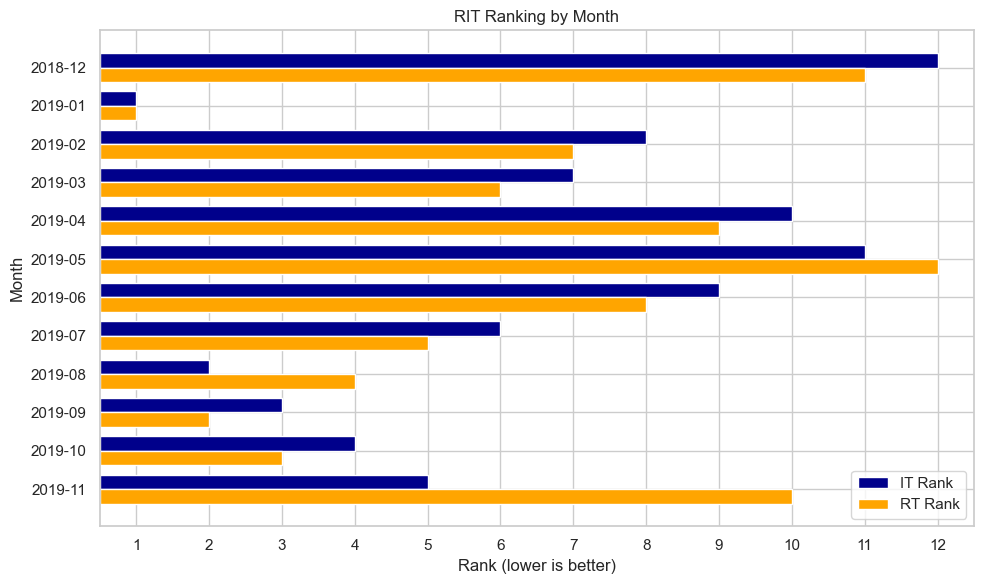

In [ ]:
# Plotting IT and RT rankings as horizontal bars

plot_data = RIT[["Month", "IT_Rank", "RT_Rank"]].copy()

month_labels = plot_data["Month"].dt.strftime("%Y-%m")      # creating a series of labels for Y-axis ($Y-%M)
month_positions = np.arange(len(plot_data))                 # creating a list of integer positions equal number the dataframe length (number of months) used as positions for for Y-axis
bar_height = 0.38
rank_axis_start = 0.5
max_rank = int(plot_data[["IT_Rank", "RT_Rank"]].to_numpy().max())

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    month_positions - bar_height / 2,       # offseting the bar up
    plot_data["IT_Rank"] - rank_axis_start,
    left=rank_axis_start,
    height=bar_height,
    color="darkblue",
    label="IT Rank",
)
ax.barh(
    month_positions + bar_height / 2,       # offseting the bar down
    plot_data["RT_Rank"] - rank_axis_start,
    left=rank_axis_start,
    height=bar_height,
    color="orange",
    label="RT Rank",
)

ax.set_yticks(month_positions, month_labels)
ax.invert_yaxis()                               # keeping months chronological from top to bottom
ax.set_xticks(range(1, max_rank + 1))
ax.set_xlim(rank_axis_start, max_rank + 0.5)

ax.set_title("RIT Ranking by Month")
ax.set_xlabel("Rank (lower is better)")
ax.set_ylabel("Month")
ax.legend()

plt.tight_layout()
plt.show()

Result:
Both rankings are pretty close most of the time range indicating a correlation between total quantity of the ordered items and their price. Interestingly, November 2019 ranks 5th for items per invoice but 10th for revenue per invoice, where rank 1 means the highest value. November’s higher order volume outweighed its lower average order value. Purchase invoices increased 37.31%, while average invoice value fell 20.97%.

Variation of monthly revenue (volatility) within 12 Months

Note. Data related to December 2019 is ignored in the following analysis due to being incomplete and therefore not useful.

In [ ]:
# Note. The dataset covers a period of 12 months while volatility is calculated per year basis
# Because the dataset covers such a short period, I would calculate instead a "coefficient of variation of monthly revenue" 

# Step 1. Calculate Monthly net revenue including refunds as it helps understand total volatility

one_year_df['Month'] = one_year_df['Date'].dt.to_period('M') #convert date to monthly period, i.e. removing day and time

monthly_net_revenue = one_year_df.groupby('Month').apply(lambda x: (x['Price_UKpounds'] * x['Quantity']).sum())

# Step 2. Calculate Volatility of Net Revenue from Dec 2018 till Dec 2019
# Note. Volatility is measured as the standard deviation of returns relative to the mean

print(f'Average monthly net revenue:', monthly_net_revenue.mean().round(2))
print(f'Standard deviation of monthly net revenue:', monthly_net_revenue.std().round(2))

volatility = 100 * monthly_net_revenue.std() / monthly_net_revenue.mean()

print(f'Variation of monthly revenue (volatility) from Dec 2018 to Nov 2019: {volatility.round(2)}%')


Average monthly net revenue: 4843979.39
Standard deviation of monthly net revenue: 1434953.04
Variation of monthly revenue (volatility) from Dec 2018 to Nov 2019: 29.62%


Recency, Frequency, Monetary (RFM) analysis for Revenue

Note. For the following dataset analysis the full time dataset was used, because analysis is not dependant on incomplete months data.

In [ ]:
# RFM analysis for Revenue 

# Creating a copy of a dataset to work on

rfm = df[
    (df['Customer_id'] != 0) &              # excluding Customer_id = "0" (unidentified users) from the analysis
    (df['Quantity'] >= 0)  &                # excluding refunds
    (~df['Order_id'].str.startswith('C'))   # excluding cancelled orders (when 'Order_id' starts with "C")
].copy()


# Calculating Gross revenue per row 

rfm['gross_revenue'] = rfm['Price_UKpounds'] * rfm['Quantity']

# Customer-level RFM metrics
rfm = (
    rfm.assign(last_purchase_date=lambda x: x.groupby('Customer_id')['Date'].transform('max'))     # adding last purchase date for each customer
    .groupby('Customer_id')
    .agg(
        last_purchase_date=('last_purchase_date', 'max'),
        frequency=('Order_id', 'nunique'),
        monetary_value=('gross_revenue', 'sum')
    )
    .reset_index()
)

# Recency: days since the customer's last purchase
analysis_date = df['Date'].max() + pd.Timedelta(days=1)                         # adding 1 day to the max date in the dataset to represent the analysis date (the day after the last transaction)
rfm['recency_days'] = (analysis_date - rfm['last_purchase_date']).dt.days       # calculating the number of days since the last purchase for each customer


# R/F/M scoring (higher score = better) 

# Recency
# Lower recency = more recent purchase = higher score.

rfm["R_score"] = pd.qcut(
    rfm["recency_days"],
    q=4,
    labels=[4, 3, 2, 1]
).astype(int)

# Frequency
# Note. I didn't use pd.qcut(X,rank(method="first")) for frequency because it would create a situation where customers with the same frequency value 
# could be assigned to different quartiles. Instead, I used pd.cut() to create custom frequency bands based on the dataset's quartiles.
# Intervals: (0, 1], (1, 2], (2, 5], (5, infinity].
# Higher frequqncy = more purchases = higher score.

rfm["F_score"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 2, 5, np.inf],
    labels=[1, 2, 3, 4],
    right=True
).astype(int)

# Higher monetary value = higher score.

rfm["M_score"] = pd.qcut(
    rfm["monetary_value"],
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

# Combining scores in a line for better readability and easier segmentation

rfm['RFM_score'] = rfm['R_score'] * 100 + rfm['F_score'] * 10 + rfm['M_score']      

# Create a custom function for a simple segment labelling

def rfm_segment(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Champions'
    elif row['R_score'] >= 2 and row['F_score'] >= 3 and row['M_score'] >= 2:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] >= 2 and row['M_score'] >= 2:
        return 'Potential Loyalists'
    elif row['R_score'] >= 3 and row['F_score'] >= 1 and row['M_score'] >= 1:
        return 'Recent Customers'
    elif row['R_score'] >= 2 and row['F_score'] <= 2 and row['M_score'] >= 2:
        return 'Promising'
    elif row['R_score'] >= 2 and row['F_score'] <= 2 and row['M_score'] <= 2:
        return 'Needs Attention'
    else:
        return 'At Risk'

# Applying the segmentation function to each row of the RFM DataFrame

rfm['segment'] = rfm.apply(rfm_segment, axis=1)


# Result:

print(rfm.head())

segment_summary = (
    rfm["segment"]
    .value_counts()
    .rename_axis("segment")
    .to_frame("customers")
)

segment_summary["customer_pct"] = (
    segment_summary["customers"] / len(rfm) * 100
).round(2)

print(segment_summary)


   Customer_id last_purchase_date  frequency  monetary_value  recency_days  \
0        12004         2019-04-26          1         1509.60           228   
1        12006         2019-05-05          1           24.76           219   
2        12008         2019-03-08          1         5689.57           277   
3        12013         2018-12-15          1           69.96           360   
4        12024         2019-06-16          1          149.52           177   

   R_score  F_score  M_score  RFM_score  segment  
0        1        1        1        111  At Risk  
1        1        1        1        111  At Risk  
2        1        1        3        113  At Risk  
3        1        1        1        111  At Risk  
4        1        1        1        111  At Risk  
                     customers  customer_pct
segment                                     
Champions                 1343         28.47
At Risk                   1206         25.57
Loyal Customers            651         13.80


Results:
Champions + Loyal Customers: 1343+651 = 1994
Champions + Loyal Customers/Total RFM population is 1994/4717 = 42.27%
At Risk / Total : 1206/4717 = 25.57%

Cohort and retention analysis of customers

Note.  Cohort analysis is performed for  1 December 2018 till 30 November 2019 data period for  creating a clear heatmap.

Cohort customer counts 	months_since_first_purchase      0      1      2      3      4      5      6   \
first_purchase_month                                                            
2018-12                      1026.0  341.0  310.0  368.0  355.0  385.0  359.0   
2019-01                       486.0   98.0  127.0  111.0  147.0  136.0  113.0   
2019-02                       437.0   83.0   80.0  114.0  115.0   98.0  105.0   
2019-03                       503.0   71.0  115.0   95.0  116.0   83.0  131.0   
2019-04                       321.0   66.0   60.0   63.0   62.0   74.0   69.0   
2019-05                       332.0   62.0   62.0   55.0   68.0   73.0   84.0   
2019-06                       274.0   48.0   41.0   60.0   62.0   79.0    NaN   
2019-07                       211.0   31.0   37.0   43.0   63.0    NaN    NaN   
2019-08                       173.0   32.0   41.0   39.0    NaN    NaN    NaN   
2019-09                       282.0   68.0   94.0    NaN    NaN    NaN    NaN   
2019

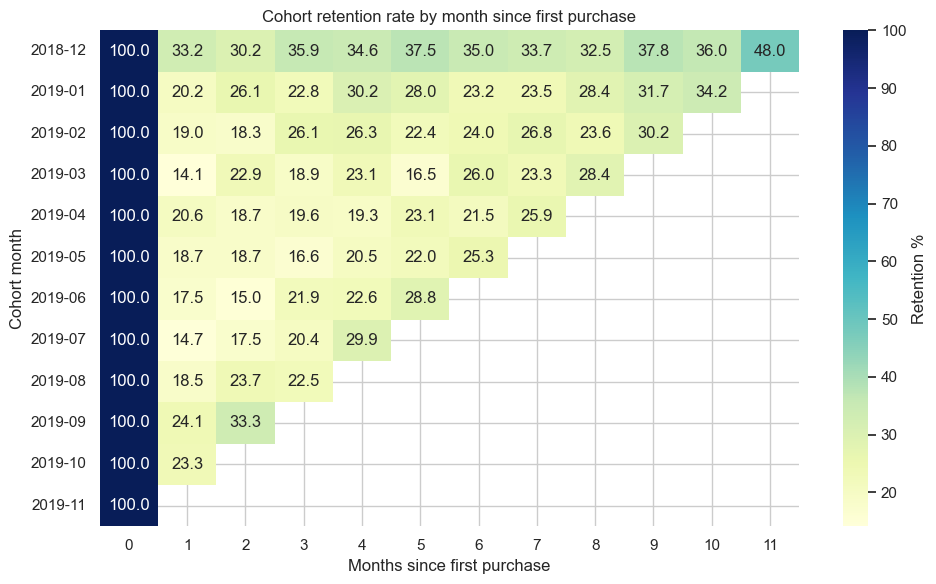


Observed-period repeat-purchase rate: 65.42 %
first_purchase_month
2018-12    33.24
2019-01    20.16
2019-02    18.99
2019-03    14.12
2019-04    20.56
2019-05    18.67
2019-06    17.52
2019-07    14.69
2019-08    18.50
2019-09    24.11
2019-10    23.28
Name: 1, dtype: float64

One-time vs repeat customers 	purchase_count
Repeat      3055
One-time    1615
Name: count, dtype: int64

New vs returning customers by month 	customer_type   New  Returning
order_month                   
2018-12        1026          0
2019-01         486        341
2019-02         437        408
2019-03         503        578
2019-04         321        617
2019-05         332        827
2019-06         274        827
2019-07         211        846
2019-08         173        824
2019-09         282       1045
2019-10         335       1099
2019-11         290       1453

Time to second purchase (days) 	count    3055.000000
mean       81.431751
std        78.317874
min         0.000000
25%        22.000000
50%  

In [ ]:
# Cohort analysis

# I use only positive orders from identified customers. I copy a dataframe to avoid changing the original data frame and to keep it for further analysis 
# Note: unidentified customers have "Customer_id" == 0 and were excluded when creating the "positive_orders" dataframe

cohort = df.loc[
    df["Customer_id"].ne(0)   # excluding unidentified users  
    & df["Quantity"].gt(0)    # excluding refunds
    & ~df["Order_id"].str.startswith("C", na=False) # excluding refunds
    & df["Date"].lt("2019-12-01")  # keeping it under a year to avoid misleading retention rates for further months 
].copy()

# Creating key cohort fields
cohort['Date'] = pd.to_datetime(cohort['Date'])
cohort['gross_revenue'] = cohort['Price_UKpounds'] * cohort['Quantity']
cohort['first_purchase_month'] = cohort.groupby('Customer_id')['Date'].transform('min').dt.to_period('M')
cohort['order_month'] = cohort['Date'].dt.to_period('M')
cohort['months_since_first_purchase'] = (
    cohort['order_month'] - cohort['first_purchase_month']
).apply(lambda x: x.n).astype(int)


# Step 1. Cohort customer counts

cohort_customer_counts = (
    cohort.groupby(['first_purchase_month', 'months_since_first_purchase'])['Customer_id']
    .nunique()
    .unstack(fill_value=0)
)

cohort_customer_counts = cohort_customer_counts.reindex(
    columns=range(cohort_customer_counts.columns.max() + 1),
    fill_value=0
).sort_index()

# Adding NaN values for unobserved months in the cohort table to avoid misleading retention rates for future months
last_complete_month = pd.Period("2019-11", freq="M")

# Allowing NaN values in the customer-count table.
cohort_customer_counts = cohort_customer_counts.astype(float)

for cohort_month in cohort_customer_counts.index:
    unobserved_months = [
        u_month
        for u_month in cohort_customer_counts.columns
        if cohort_month + int(u_month) > last_complete_month
    ]

    cohort_customer_counts.loc[
        cohort_month, unobserved_months
    ] = np.nan

print(f'Cohort customer counts \t{cohort_customer_counts}')


# Step 2. Cohort retention-rate heatmap

cohort_sizes = cohort_customer_counts[0]
retention_rate = (
    cohort_customer_counts.div(cohort_sizes, axis=0)
    .mul(100)
    .round(2)
)

retention_rate.index = retention_rate.index.astype(str)

plt.figure(figsize=(10, 6))
sns.heatmap(
    retention_rate,
    mask=retention_rate.isna(),    # hiding NaN values in the heatmap
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention %'}
)
plt.title('Cohort retention rate by month since first purchase')
plt.xlabel('Months since first purchase')
plt.ylabel('Cohort month')

plt.tight_layout()
plt.show()


# Step 3. Repeat-customer rate

# This rate measures the percentage of identified customers with at least two distinct purchase invoices 
# during the observed period. Customers first observed later have less time to make another purchase.

customer_purchase_counts = (
    cohort.groupby('Customer_id')['Order_id']
    .nunique()
    .rename('purchase_count')
)

repeat_customer_rate = (customer_purchase_counts > 1).mean()

print(f'\nObserved-period repeat-purchase rate:', round(repeat_customer_rate * 100, 2), '%')

# Comparing month-one retention across eligible cohorts

month_1_retention = retention_rate[1].dropna()
print(month_1_retention)

# Step 4. One-time vs repeat customers

customer_type_counts = (
    (customer_purchase_counts > 1)
    .map({True: 'Repeat', False: 'One-time'})
    .value_counts()
)

print(f'\nOne-time vs repeat customers \t{customer_type_counts}')


# Step 5. New vs returning customers by month

monthly_customer_type = (
    cohort.sort_values(['Customer_id', 'Date'])
    .groupby(['Customer_id', 'order_month'])
    .agg(
        first_purchase_month=('first_purchase_month', 'first'),
        gross_revenue=('gross_revenue', 'sum')
    )
    .reset_index()
)

monthly_customer_type['customer_type'] = np.where(
    monthly_customer_type['order_month'] == monthly_customer_type['first_purchase_month'],
    'New',
    'Returning'
)

new_vs_returning_monthly = (
    monthly_customer_type.groupby(['order_month', 'customer_type'])['Customer_id']
    .nunique()
    .unstack(fill_value=0)
)

print(f'\nNew vs returning customers by month \t{new_vs_returning_monthly}')


# Step 6. Time to second purchase

customer_order_dates = (
    cohort[["Customer_id", "Order_id", "Date"]]
    .drop_duplicates(["Customer_id", "Order_id"])
    .sort_values(["Customer_id", "Date", "Order_id"])
    .groupby("Customer_id")["Date"]
    .agg(list)
)

time_to_second_purchase = (
    customer_order_dates
    .apply(lambda dates: (dates[1] - dates[0]).days if len(dates) >= 2 else np.nan)
    .dropna()
)

print(f'\nTime to second purchase (days) \t{time_to_second_purchase.describe()}')


# Step 7. Revenue from new vs returning customers

monthly_revenue_by_type = (
    monthly_customer_type.groupby(['order_month', 'customer_type'])['gross_revenue']
    .sum()
    .unstack(fill_value=0)
)


# Step 8. Displaying the results 

print(f'\nRevenue from new vs returning customers\t{monthly_revenue_by_type}')

Result: 

The analysis shows both new customers and returning customers contribute a significant portion to gross revenue. This indicates that while acquiring new customers is important, retaining existing customers is also crucial for sustained revenue growth.

Observed-period repeat-purchase rate was 65.42 % with 81.4 days being the mean time from first to second purchase among customers observed making a second purchase. Repeat customers were 3055 while one-time purchasers 1615.

Countries performance analysis

Note. Limited-time dataset was used because the analysis may be negatively impacted by an incomplete month data.

In [ ]:
# Countries performance analysis - revenue

country_performance = one_year_df.copy()

# Step 1. Net revenue per country

net_revenue_country = (
    country_performance.groupby('Country')
    .apply(lambda x: (x['Price_UKpounds'] * x['Quantity']).sum())
    .round(2)  
    .rename('net_revenue')
    .to_frame()
)

# Step 2. Gross revenue per country

gross_revenue_country = (
    country_performance.loc[country_performance['Quantity'] >= 0]
    .groupby('Country')
    .apply(lambda x: (x['Price_UKpounds'] * x['Quantity']).sum())
    .round(2)  
    .rename('gross_revenue')
    .to_frame()
)

# Step 3. Refunds per country

refunds_country = (
    country_performance.loc[country_performance['Quantity'] < 0]
    .groupby('Country')
    .apply(lambda x: (-1 * (x['Price_UKpounds'] * x['Quantity'])).sum()) # multiplied  to -1 to have positive refunds values
    .round(2)    
    .rename('refunds')
    .to_frame()
)

# Step 4. Final table with net revenue, gross revenue, and refunds per country

country_revenue = (
    net_revenue_country
    .join(gross_revenue_country, how='left')
    .join(refunds_country, how='left')
    .fillna(0)
)

country_revenue = country_revenue.apply(
    lambda x: x['refunds'] / x['gross_revenue'] * 100, axis=1).round(2).rename(
    'Refunds_revenue_pct').to_frame().join(country_revenue, how='left'
    ).fillna(0)

print(country_revenue.sort_values('net_revenue', ascending=False).head(10))

                Refunds_revenue_pct  net_revenue  gross_revenue     refunds
Country                                                                    
United Kingdom                 3.96  48028656.70    50007787.81  1979131.11
Netherlands                    0.18   2097361.87     2101104.07     3742.20
Ireland(EIRE)                  3.11   1633382.55     1685727.12    52344.57
Germany                        1.54   1324081.02     1344836.75    20755.73
France                         0.99   1292949.31     1305890.87    12941.56
Australia                      0.69    988562.45      995414.01     6851.56
Sweden                         1.39    396000.61      401590.29     5589.68
Switzerland                    0.98    358146.32      361691.96     3545.64
Japan                          3.26    283596.78      293155.44     9558.66
Belgium                        0.29    264060.71      264820.85      760.14


In [ ]:
# Checking which countries have highest refunds pct

country_revenue.sort_values('Refunds_revenue_pct',ascending=False).head(10)

,Refunds_revenue_pct,net_revenue,gross_revenue,refunds
Country,,,,
USA,48.78,14915.10,29120.13,14205.03
Czech Republic,11.96,6756.80,7674.44,917.64
Saudi Arabia,6.84,903.15,969.50,66.35
Spain,5.44,263757.31,278920.04,15162.73
United Kingdom,3.96,48028656.70,50007787.81,1979131.11
Japan,3.26,283596.78,293155.44,9558.66
Ireland(EIRE),3.11,1633382.55,1685727.12,52344.57
Germany,1.54,1324081.02,1344836.75,20755.73
Italy,1.46,77091.17,78230.19,1139.02


In [ ]:
# Countries performance review 
# Combining financial impact, invoice counts, customer counts, and units.

country_review = country_revenue[
    ["gross_revenue", "refunds", "net_revenue"]
].rename(columns={
    "gross_revenue": "gross_sales",
    "refunds": "refunds"
})

sold_products = one_year_df.loc[one_year_df["Quantity"] >= 0]
refunded_products = one_year_df.loc[one_year_df["Quantity"] < 0]

sold_products_count = sold_products.groupby("Country").agg(
    sold_orders=("Order_id", "nunique"),
    purchasing_customers=(
        "Customer_id", lambda s: s[s != 0].nunique()
    ),
    sold_products_number=("Quantity", "sum")
)

refunded_products_count = refunded_products.groupby("Country").agg(
    refunded_orders=("Order_id", "nunique"),
    refunded_products_number=("Quantity", lambda s: -s.sum())
)

country_review = (
    country_review
    .join(sold_products_count)
    .join(refunded_products_count)
)

count_columns = [
    "sold_orders", "purchasing_customers", "sold_products_number",
    "refunded_orders", "refunded_products_number"
]
country_review[count_columns] = (
    country_review[count_columns].fillna(0).astype(int)
)

# Undefined ratios remain missing when their denominator is zero.

country_review["refunds_value_to_sales_pct"] = (
    100 * country_review["refunds"]
    / country_review["gross_sales"].replace(0, np.nan)
)

country_review["refunds_orders_share_pct"] = (
    100 * country_review["refunded_orders"]
    / (
        country_review["sold_orders"]
        + country_review["refunded_orders"]
    ).replace(0, np.nan)
)

country_review["refunded_products_to_sold_pct"] = (
    100 * country_review["refunded_products_number"]
    / country_review["sold_products_number"].replace(0, np.nan)
)

country_review.sort_values("refunds", ascending=False).head()

,gross_sales,refunds,net_revenue,sold_orders,purchasing_customers,sold_products_number,refunded_orders,refunded_products_number,refunds_value_to_sales_pct,refunds_orders_share_pct,refunded_products_to_sold_pct
Country,,,,,,,,,,,
United Kingdom,50007787.81,1979131.11,48028656.70,17163,4263,4364992,2918,171757,3.957646,14.531149,3.934875
Ireland(EIRE),1685727.12,52344.57,1633382.55,267,13,142448,54,4148,3.105163,16.822430,2.911940
Germany,1344836.75,20755.73,1324081.02,435,90,116302,128,1709,1.543364,22.735346,1.469450
Spain,278920.04,15162.73,263757.31,76,22,23213,10,1090,5.436228,11.627907,4.695645
USA,29120.13,14205.03,14915.10,6,3,2435,1,1228,48.780792,14.285714,50.431211


In [ ]:
# Adding flags for countries setting minimum thresholds assuming that
# they would be useful for country performance review and buisness decisions prioretization.
# All thresholds are suggested values and can be adjusted based on buisness needs.
 
MIN_PURCHASE_ORDERS = 20
MIN_PURCHASING_CUSTOMERS = 5
REVIEW_VALUE_RATIO_PCT = 5.0
REVIEW_REFUND_VALUE_GBP = 10000

country_review["limited_purchase_history"] = (
    (country_review["sold_orders"] < MIN_PURCHASE_ORDERS)
    | (
        country_review["purchasing_customers"]
        < MIN_PURCHASING_CUSTOMERS
    )
)

country_review["review_value_ratio"] = (
    country_review["refunds_value_to_sales_pct"]
    >= REVIEW_VALUE_RATIO_PCT
).where(
    country_review["refunds_value_to_sales_pct"].notna(),
    pd.NA
).astype("boolean")

country_review["review_refund_value"] = (
    country_review["refunds"] >= REVIEW_REFUND_VALUE_GBP
)

# Showing the largest absolute refund values first.

country_review = country_review.sort_values(
    "refunds", ascending=False
)

country_review.round(2)

,gross_sales,refunds,net_revenue,sold_orders,purchasing_customers,sold_products_number,refunded_orders,refunded_products_number,refunds_value_to_sales_pct,refunds_orders_share_pct,refunded_products_to_sold_pct,limited_purchase_history,review_value_ratio,review_refund_value
Country,,,,,,,,,,,,,,
United Kingdom,50007787.81,1979131.11,48028656.70,17163,4263,4364992,2918,171757,3.96,14.53,3.93,False,False,True
Ireland(EIRE),1685727.12,52344.57,1633382.55,267,13,142448,54,4148,3.11,16.82,2.91,False,False,True
Germany,1344836.75,20755.73,1324081.02,435,90,116302,128,1709,1.54,22.74,1.47,False,False,True
Spain,278920.04,15162.73,263757.31,76,22,23213,10,1090,5.44,11.63,4.70,False,True,True
USA,29120.13,14205.03,14915.10,6,3,2435,1,1228,48.78,14.29,50.43,True,True,True
France,1305890.87,12941.56,1292949.31,387,86,114793,57,1456,0.99,12.84,1.27,False,False,True
Japan,293155.44,9558.66,283596.78,20,8,26053,5,746,3.26,20.00,2.86,False,False,False
Australia,995414.01,6851.56,988562.45,62,9,85742,11,555,0.69,15.07,0.65,False,False,False
Sweden,401590.29,5589.68,396000.61,32,7,35807,7,403,1.39,17.95,1.13,False,False,False


 Result:

The country analysis covers 1 December 2018–30 November 2019.
The ten largest countries by net revenue each have refunds-to-sales value ratios below 5% (see the "review_value_ratio" column). 
However, several have substantially higher refunds-to-orders ratios, so the measures require separate interpretation.

The UK has the largest absolute refunds value of 1979131.11 UK pounds, representing 3.96% of gross sales. Refund orders share of all orders (number of refund orders / (number of purchase + refund orders)) accounts for 14.53% of all orders from this country.
The sheer magnitutude of sales and refunds sets UK a priority target for the financial review and buisness stratagy optimization.

Germany refund orders share of all orders  is 22.74% , while its refunds-to-sales value ratio is 1.54%.The Germany case indicates how useful it is comparing the metrics of orders and sales impact together.

The USA has a refunds-to-sales value ratio of 48.78% and a refund orders share of all orders of 14.29%.
This data belongs to six purchase orders, one refund order, and three purchasing customers. 
It is a small sample and therefore the result may not be representative compared to other countries in the dataset.

Saudi Arabia has one purchase order and one refund order, producing a 50% refund orders share of all orders. It was also has 80 products sold and 5 products refunded. Note, with the limited purchasing history it is hard to establish the original-order relationship
and therefore the reason behind the values in the table remain unverified.

The table summary and the sewt thresholds help to identify areas for further investigation. 
The values variations may stem from product quality issues, customer dissatisfaction with the product or it's marketing, order corrections, or other causes.


Products cancellation analysis

Note. Full time dataset was used, becaue the analysis is not affected by incomplete month data.

In [ ]:
# Cancellation/refunds analysis for products

# Creating a copy of a dataframe to work on

refunded_products = df.copy()

# Calculating net and gross product revenue and cancelled products costs

refunded_products['gross_product_revenue'] = np.where(
    refunded_products['Quantity'] >= 0,
    refunded_products['Price_UKpounds'] * refunded_products['Quantity'],
    0
)

refunded_products['cancelled_product_costs'] = np.where(
    refunded_products['Quantity'] < 0,
    refunded_products['Price_UKpounds'] * (refunded_products['Quantity'].abs()),
    0
)

refunded_products = (
    refunded_products.groupby(['Product_id', 'Product_name'], as_index=False)
    .agg(
        items_id=('Product_id', 'first'),
        item_avg_price=('Price_UKpounds', 'mean'), 
        net_items=('Quantity', 'sum'),
        gross_sold_items=('Quantity', lambda x: x.loc[x >= 0].sum()),
        total_returned_items=('Quantity', lambda x: x.loc[x < 0].abs().sum()),
        #total_orders = ('Orders_id', lambda x: ~x.str.startswith('C').nunique()),
        #total_cancelled_orders = ('Orders_id', lambda x: x.str.startswith('C').nunique()),
        total_gross_revenue=('gross_product_revenue', 'sum'),
        total_refunds_costs=('cancelled_product_costs', 'sum')
    ).sort_values('total_refunds_costs', ascending=False)
)

refunded_products['total_net_revenue'] = refunded_products['total_gross_revenue'] - refunded_products['total_refunds_costs']
refunded_products.sort_values('total_net_revenue', ascending=False).head(10)

# Note. Some cancellation prices do not fully reverse the original sales prices like 'Paper Craft Little Birdie' (id: 23843).
# Therefore, a net revenue is based on recorded transaction amounts and becomes positive/negative even for 0 net items.


,Product_id,Product_name,items_id,item_avg_price,net_items,gross_sold_items,total_returned_items,total_gross_revenue,total_refunds_costs,total_net_revenue
1091,22197,Popcorn Holder,22197,10.784966,56427,56898,471,587193.70,4147.43,583046.27
2834,84077,World War 2 Gliders Asstd Designs,84077,10.275416,53751,54951,1200,568722.59,12564.96,556157.63
2443,23843,Paper Craft Little Birdie,23843,9.285000,0,80995,80995,1002718.10,501359.05,501359.05
3264,85123A,Cream Hanging Heart T-Light Holder,85123A,13.078777,35354,37932,2578,484288.37,33190.99,451097.38
3088,84879,Assorted Colour Bird Ornament,84879,11.637344,36338,36386,48,420036.88,575.04,419461.84
424,21212,Pack Of 72 Retrospot Cake Cases,21212,10.773745,36208,36492,284,391241.08,3060.42,388180.66
1923,23084,Rabbit Night Light,23084,11.042849,30631,30739,108,328509.89,1235.68,327274.21
3249,85099B,Jumbo Bag Red Retrospot,85099B,6.393279,47260,48375,1115,296584.47,6730.52,289853.95
1292,22423,Regency Cakestand 3 Tier,22423,23.228470,13007,13862,855,306894.75,18148.61,288746.14
1356,22492,Mini Paint Set Vintage,22492,10.736538,26437,26633,196,287001.66,2130.74,284870.92


In [ ]:
# Checking for products that have more returned items than sold items. This is a clear indication of data entry errors
refunded_products.query('gross_sold_items < total_returned_items').sort_values('total_returned_items', ascending=False).head()

# Note. This result is empty because the selected cleaning policy already excluded products with more cancelled/refunded units than sold units.

,Product_id,Product_name,items_id,item_avg_price,net_items,gross_sold_items,total_returned_items,total_gross_revenue,total_refunds_costs,total_net_revenue


In [ ]:
# Calculating product refunds percentage and product refunds cost percentage

refunded_products['product_refunds_pct'] = (refunded_products['total_returned_items'] / refunded_products['gross_sold_items'] * 100).round(2)

refunded_products['product_refunds_cost_pct'] = (refunded_products['total_refunds_costs'] / refunded_products['total_gross_revenue'] * 100).round(2)


refunded_products = refunded_products[['Product_name', 'items_id','item_avg_price','net_items', 'product_refunds_pct','total_net_revenue', 'product_refunds_cost_pct']]
refunded_products.sort_values('product_refunds_cost_pct', ascending=False).head(10)

,Product_name,items_id,item_avg_price,net_items,product_refunds_pct,total_net_revenue,product_refunds_cost_pct
704,Glass Cake Cover And Plate,21667,25.570000,0,100.00,0.00,100.00
2787,Black Cherry Lights,79323B,17.170000,0,100.00,0.00,100.00
696,Hanging Ridge Glass T-Light Holder,21655,11.980000,0,100.00,0.00,100.00
3215,White Beaded Garland String 20light,85047,16.555000,0,100.00,0.82,98.37
2001,Medium Ceramic Top Storage Jar,23166,11.122038,3539,95.46,38712.22,95.61
3367,Set Of 3 Babushka Stacking Tins,85232B,15.245263,19,93.07,295.34,92.96
2866,Rotating Silver Angels T-Light Hldr,84347,12.272521,103,98.91,13345.50,87.83
1948,Pantry Chopping Board,23113,15.334444,208,81.98,3050.21,82.73
220,Goldie Looking Mirror,20821,14.310000,5,70.59,60.44,75.26
1623,Chalkboard Kitchen Organiser,22769,45.898000,1,90.91,155.02,68.28


In [ ]:
# filtering all products with product_refunds_cost_pct >= 50% to identify products with high cost of refunds. This maybe useful for product quality and customer satisfaction analysis.

refunded_products_filtered = refunded_products.copy()
refunded_products_filtered = refunded_products_filtered[refunded_products_filtered['product_refunds_cost_pct'] >= 50]
refunded_products_filtered.sort_values('product_refunds_cost_pct', ascending=False).reset_index().head(20)

,index,Product_name,items_id,item_avg_price,net_items,product_refunds_pct,total_net_revenue,product_refunds_cost_pct
0,696,Hanging Ridge Glass T-Light Holder,21655,11.980000,0,100.00,0.00,100.00
1,704,Glass Cake Cover And Plate,21667,25.570000,0,100.00,0.00,100.00
2,2787,Black Cherry Lights,79323B,17.170000,0,100.00,0.00,100.00
3,3215,White Beaded Garland String 20light,85047,16.555000,0,100.00,0.82,98.37
4,2001,Medium Ceramic Top Storage Jar,23166,11.122038,3539,95.46,38712.22,95.61
5,3367,Set Of 3 Babushka Stacking Tins,85232B,15.245263,19,93.07,295.34,92.96
6,2866,Rotating Silver Angels T-Light Hldr,84347,12.272521,103,98.91,13345.50,87.83
7,1948,Pantry Chopping Board,23113,15.334444,208,81.98,3050.21,82.73
8,220,Goldie Looking Mirror,20821,14.310000,5,70.59,60.44,75.26
9,1623,Chalkboard Kitchen Organiser,22769,45.898000,1,90.91,155.02,68.28


In [ ]:
# Segmenting returns of products by creating a custom function for labelling

def product_refunds_segment(row):
    if row['product_refunds_pct'] >= 90 and row['product_refunds_cost_pct'] >= 75:
        return 'Very high products refunds and high refunds cost'
    elif row['product_refunds_pct'] >= 75 and row['product_refunds_cost_pct'] >= 75:
        return 'High products refunds and high refunds cost'
    elif row['product_refunds_pct'] >= 75 and row['product_refunds_cost_pct'] < 75:
        return 'High products refunds but low refunds cost'
    elif row['product_refunds_pct'] < 75 and row['product_refunds_cost_pct'] >= 75:
        return 'Moderate products refunds and high refunds cost'
    else:
        return 'Moderate products refunds but low refunds cost'


# Applying the segmentation function to each row of the RFM DataFrame

refunded_products_filtered['segment'] = refunded_products_filtered.apply(product_refunds_segment, axis=1)


# Result

print("Refunded products segments:")
print(refunded_products_filtered)
print('\nSegment counts:')
print(refunded_products_filtered['segment'].value_counts())

Refunded products segments:
                             Product_name items_id  item_avg_price  net_items  \
2001       Medium Ceramic Top Storage Jar    23166       11.122038       3539   
2443            Paper Craft Little Birdie    23843        9.285000          0   
2866  Rotating Silver Angels T-Light Hldr    84347       12.272521        103   
1948                Pantry Chopping Board    23113       15.334444        208   
3367      Set Of 3 Babushka Stacking Tins   85232B       15.245263         19   
2618                 Blue Voile Lampshade   47351B       13.188000         38   
696    Hanging Ridge Glass T-Light Holder    21655       11.980000          0   
1623         Chalkboard Kitchen Organiser    22769       45.898000          1   
3667       Black Diamante Expandable Ring   90185C       14.575385         10   
220                 Goldie Looking Mirror    20821       14.310000          5   
3024      Pink Foxglove Artiifcial Flower   84798A       12.860000         11   


Result:

17 products were identified using "refund value / gross product revenue" metric above 50%. 

The products were divided into 5 segments basing on the returned products amount and refunds costs.

7 products fall into 'Very high products refunds and high refunds cost', 2 products into 'High products refunds and high refunds cost', and
1 product into 'Moderate products refunds and high refunds cost'. 

While all 17 products should be investigate for refunds reasons, these should have higher priority due tot heir high refunds costs.

Selecting only the products which refunded quantity is higher than sold quantity

In [ ]:
# Filtering to show only products with high refunds costs 

high_product_refunds = refunded_products_filtered['Product_name'].to_list()
refunded_products_orders_analysis = df[df['Product_name'].isin(high_product_refunds)].copy().sort_values('Product_name')
refunded_products_orders_analysis.head()

,Order_id,Date,Product_id,Product_name,Price_UKpounds,Quantity,Customer_id,Country
449672,543747,2019-02-11,79323B,Black Cherry Lights,17.17,8,13672,United Kingdom
449873,C543745,2019-02-11,79323B,Black Cherry Lights,17.17,-4,13672,United Kingdom
491331,C540307,2019-01-06,79323B,Black Cherry Lights,17.17,-4,15823,United Kingdom
367926,551270,2019-04-27,90185C,Black Diamante Expandable Ring,14.61,6,15891,United Kingdom
112432,573585,2019-10-31,90185C,Black Diamante Expandable Ring,14.50,1,14585,United Kingdom


In [ ]:
# counting the number of orders placed for the highly refunded orders (refunded >= 50% from all products ordered)
number_of_highly_refunded_products_orders = refunded_products_orders_analysis.query('Quantity >= 0').groupby("Product_name")["Order_id"].nunique().sort_values()

# counting the number of cancellation orders placed for the highly refunded orders (refunded >= 50% from all products ordered)
number_of_highly_refunded_products_orders_cancellations = refunded_products_orders_analysis.query('Quantity < 0').groupby("Product_name")["Order_id"].nunique().sort_values()

#combine them into a single table for better comparison
table_of_highly_refunded_products_orders = pd.concat([number_of_highly_refunded_products_orders, number_of_highly_refunded_products_orders_cancellations], axis=1)

# name columns
table_of_highly_refunded_products_orders.columns = ['number_of_orders', 'number_of_cancellations']
print(table_of_highly_refunded_products_orders)

                                     number_of_orders  number_of_cancellations
Product_name                                                                  
Black Cherry Lights                                 1                        2
Glass Cake Cover And Plate                          1                        1
Paper Craft Little Birdie                           1                        1
Hanging Ridge Glass T-Light Holder                  2                        3
Set 10 Cards Hanging Baubles 17080                  2                        1
White Beaded Garland String 20light                 2                        2
Blue Tiled Tray                                     4                        1
Pink Foxglove Artiifcial Flower                     4                        1
Goldie Looking Mirror                               6                        2
Chalkboard Kitchen Organiser                        8                        2
Folk Art Greeting Card Pack/12                      

In [ ]:
# Because the dataset is time-limited, it can include notes and invoices which might belong to transactions performed outside of the investigated time window.
# I filter results to show only products for which cancellation number is higher than order number

table_of_highly_refunded_products_orders_filtered = table_of_highly_refunded_products_orders[table_of_highly_refunded_products_orders['number_of_orders'] < table_of_highly_refunded_products_orders['number_of_cancellations']]
table_of_highly_refunded_products_orders_filtered

print(f"Highly refunded product:\n{df[df['Product_name'].isin(table_of_highly_refunded_products_orders_filtered.index)][['Product_name', 'Product_id']].drop_duplicates().sort_values('Product_id').reset_index(drop=True)}")

Highly refunded product:
                         Product_name Product_id
0  Hanging Ridge Glass T-Light Holder      21655
1                 Black Cherry Lights     79323B


Result: 

2 products were identified with number of cancellations higher than the number of orders. These are 'Black Cherry Lights' (id: 79323B) and 'Hanging Ridge Glass T-Light Holder' (id: 21655).

With above result in mind, all 17 products should be investigated further and may be related to limited purchasing history in the dataset. 12 products have more purchase orders than refund orders, three with equal counts, and two with more refund orders.


Phase 3 finished successfully.